# Hyperparameter sensibility TDV
```Authors: Paul Alvarez updated: 20261409```

El presente notebook explora, mediante un breve análisis de sensibilidad, diferentes variaciones de los valores iniciales o óptimos propuestos (sobre el datasetpor Kobler et. al. para el algoritmo Total Deep Variation. Se busca comprender que resalta o perjudica el rendimiento del algoritmo. Específicamente, para esta tarea se considerarán los siguientes hiperparámetros $\sigma$ (que define el ruido normal que se espera del imagen input), $\lambda$ (como el término de fidelidad de la ecuación de energía), $T$ y $S$ (que conforman $\tau$, el cual denota el tamaño del paso del algoritmo).


In [1]:
# requeriments
import sys
import os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path: sys.path.append(root_path)
import imageio.v2 as imageio
import numpy as np
import torch
import bm3d
import matplotlib.pyplot as plt
from tdv import model
from tdv.denoise_utils import apply_vn, check_color, denoise_z, load_model, psnr, test_img
from skimage.metrics import structural_similarity as ssim
from skimage.restoration import denoise_tv_chambolle, denoise_bilateral, denoise_wavelet, estimate_sigma
from skimage import data, img_as_float
from skimage.util import random_noise
from astropy.io import fits

## Setup

In [ ]:
# define the evaluation metric
def psnr(x, y): 
    return 20*np.log10(1.0/np.sqrt(np.mean((x-y) ** 2)))

# define the application of the VN
def apply_vn(x_0, z, vn, sigma, sigma_ref=25, scale= True):
    # tranform to reference noise level
    scale = 1
    if scale: scale = sigma_ref/sigma
    x = vn(x_0 * scale, z * scale)
    # convert back to original scale
    x = [j/scale for j in x]
    return x

def check_color(raw_image):
    # check color of the input image and slice the img if necesary (+3 channels)
    y = None
    color = None
    if raw_image.ndim == 2 or (raw_image.ndim == 3 and raw_image.shape[-1] == 1):
        color = "gray"
        #y = np.mean(raw_image, 2, keepdims=True)
        y = raw_image[:, :, np.newaxis] if raw_image.ndim == 2 else raw_image
    elif raw_image.ndim == 3 and raw_image.shape[-1] in (3, 4):
        color = "color"
        y = raw_image[:, :, :3] # chop down 3 channels
    else:
        raise ValueError('Expected an HxW, HxWx1, HxWx3 or HxWx4 image')

    return y, color


def load_model(color):
    # load the model state dict
    checkpoint = torch.load(os.path.join('..', 'tdv/checkpoints', f'tdv3-3-25-f32-{color}.pth'), map_location=torch.device('cpu'))

    # get the variational network with the TDV regularizer
    vn = model.VNet(checkpoint['config'], efficient=False)
    vn.load_state_dict(checkpoint['model'])

    return vn, checkpoint

def denoise_z(vn, z, sigma=25, sigma_ref=25, scale=True):
    z_th = torch.from_numpy(np.transpose(z, (2,0,1))[None])
    
    with torch.no_grad():
        x_th = apply_vn(z_th, z_th, vn, sigma, sigma_ref, scale)
    x_S = np.transpose(x_th[-1][0].cpu().numpy(), (1,2,0))

    return x_S


def test_img(vn, img, sigma, add_noise=True, noisy_img_path=None, n_bits = 8, scale= True):
    max_value = 2**n_bits - 1
    sigma_ref = 25
    img = img.astype(np.float32)

    if add_noise:
        y, color = check_color(img)
        z = y + sigma / max_value * np.random.randn(*y.shape).astype(np.float32)
    else:
        z, color = check_color(img)
        y = None # no ground truth img

    # push the images to torch
    #y_th = torch.from_numpy(np.transpose(y, (2,0,1))[None])
    x_S = denoise_z(vn, z, sigma, sigma_ref, scale)

    return z, x_S, y

def plot_results(z, x_S, y=None, sigma=25, figsize= (18, 12)):

    """
    z: noisy image
    x_S: denoised image
    y: ground truth
    """

    z, x_S = np.squeeze(z), np.squeeze(x_S)
    y = np.squeeze(y) if y is not None else None

    c_axis = -1 if z.ndim == 3 else None
    cmap = 'gray' if z.ndim == 2 else None

    if y is not None:

        fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=figsize)

        ax[0].imshow(np.clip(z, 0, 1), cmap=cmap)
        ax[0].set_title(rf'z ($\sigma$={sigma})')
        ax[0].set_xlabel(f'PSNR={psnr(z,y):.2f}dB, 'f'SSIM={ssim(z,y,data_range=1,channel_axis=c_axis):.4f}')
        ax[1].imshow(np.clip(x_S, 0, 1), cmap=cmap)
        ax[1].set_title('x_S')
        ax[1].set_xlabel(f'PSNR={psnr(x_S,y):.2f}dB, 'f'SSIM={ssim(x_S,y,data_range=1,channel_axis=c_axis):.4f}')
        ax[2].imshow(np.clip(y, 0, 1), cmap=cmap)
        ax[2].set_title('y')

    else:

        fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(15, 5))

        ax[0].imshow(np.clip(z, 0, 1), cmap=cmap)
        ax[0].set_title('Noisy')
        ax[1].imshow(np.clip(x_S, 0, 1), cmap=cmap)
        ax[1].set_title('Denoised')

    plt.show()

In [17]:
# test/get the variational network with the TDV regularizer
vn_color, checkpoint = load_model("color")

# checkpoint and learned params
print(checkpoint['config'])
print("S:", vn_color.S)
print("T:", vn_color.T.item())
print("lambda:", vn_color.lmbda.item())

{'S': 10, 'R': {'type': 'tdv', 'config': {'in_channels': 3, 'out_channels': 1, 'num_features': 32, 'num_scales': 3, 'num_mb': 3, 'multiplier': 1, 'efficient': True}}, 'D': {'type': 'denoise', 'config': {'use_prox': True}}, 'T_mode': 'learned', 'T': {'init': 0.001, 'min': 0, 'max': 1000}, 'lambda_mode': 'learned', 'lambda': {'init': 0.01, 'min': 0, 'max': 1000}, 'pad': 0}
S: 10
T: 0.024726811796426773
lambda: 0.1045219898223877


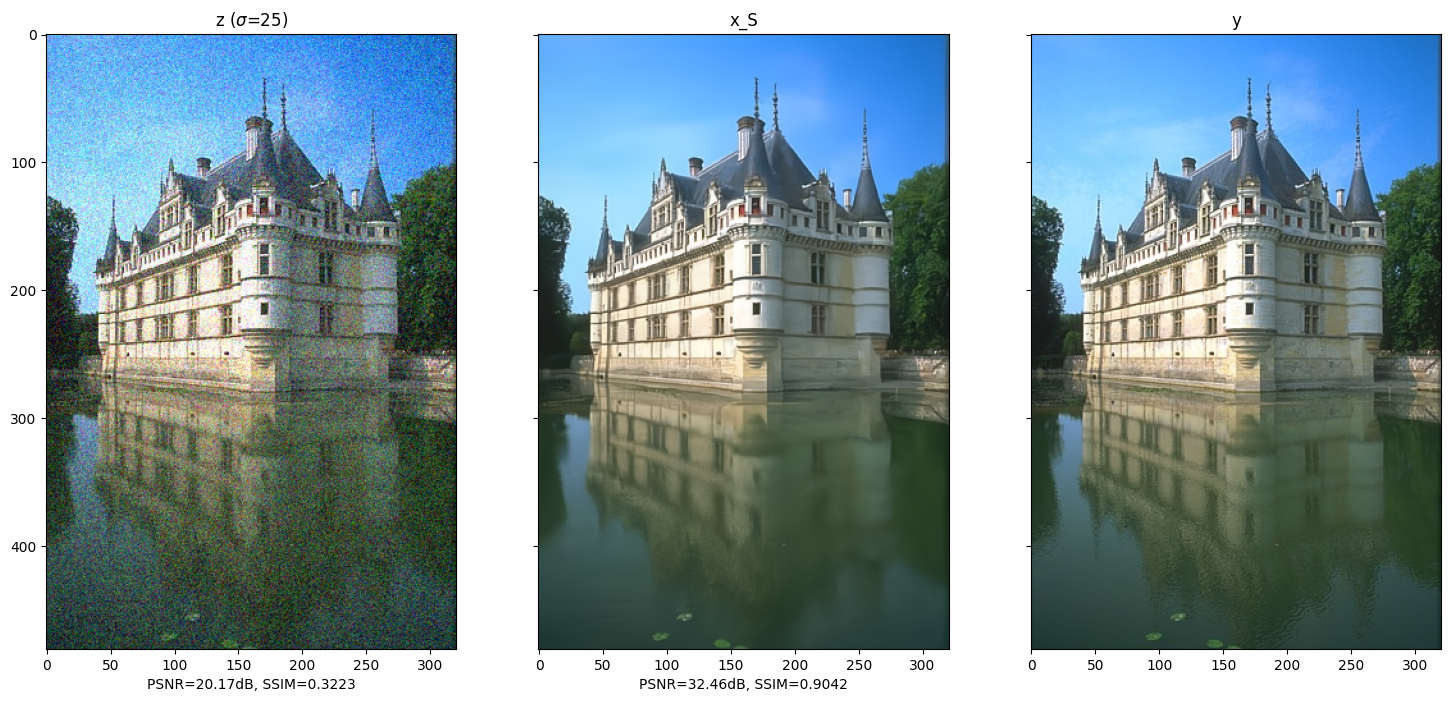

In [18]:
# Plot one img
img_path = os.path.join('..', 'data', 'water-castle.png')
img_01 = imageio.imread(img_path).astype(np.float32) / 255
z, x, y = test_img(vn_color, img_01, sigma= 25)
plot_results(z, x, y, sigma = 25)

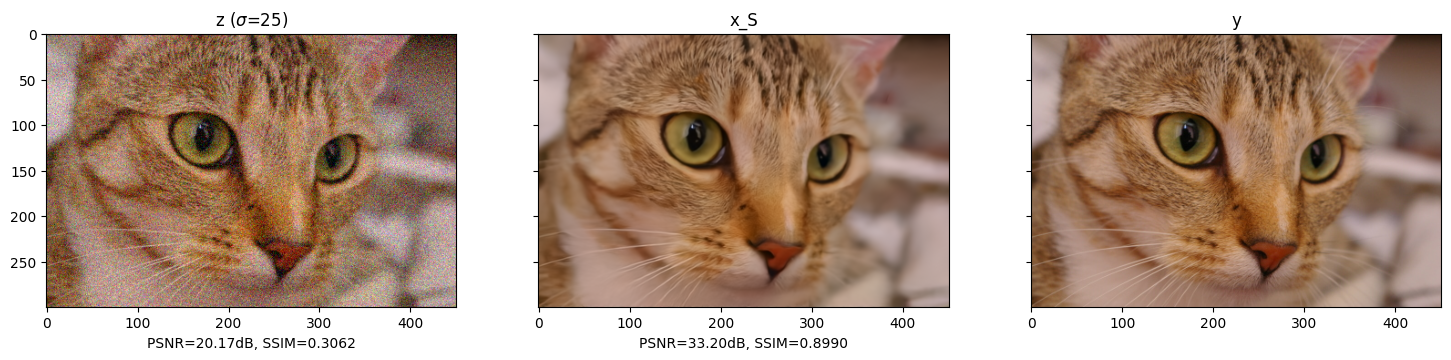

In [19]:
# plot one img
img_02 = img_as_float(data.chelsea()) 
z, x, y = test_img(vn_color, img_02, sigma= 25)
plot_results(z, x, y, sigma = 25)

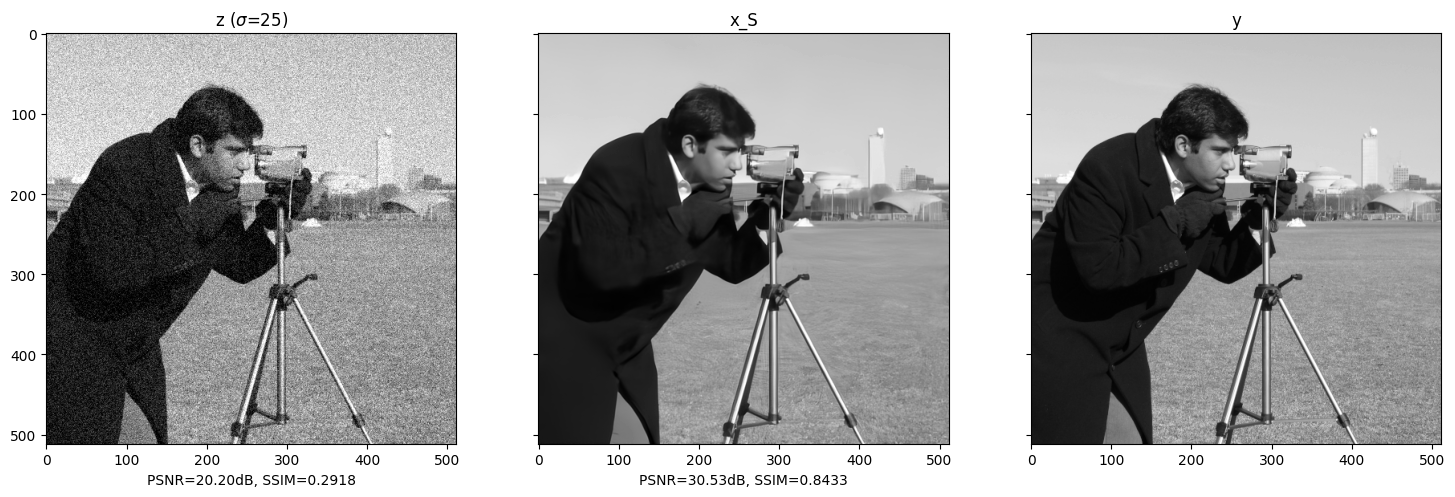

In [20]:
# plot one img
img_03 = img_as_float(data.camera())
_, color = check_color(img_03)
vn_gray, checkpoint = load_model(color)
z, x, y = test_img(vn_gray, img_03, sigma= 25)
plot_results(z, x, y, sigma = 25)

## $\sigma$ values

El hiperparámetro $\sigma$ denota la desviación estándar del ruido gaussiano aplicado a la imagen de referencia. A mayor valor de $\sigma$ la imagen estará más contaminada con este tipo de ruido, por ende, con menores valores de $PSNR$ y $SSIM$ respecto al dato original. En este caso, los pesos de $TDV$ fueron obtenidos considerando un entrenamiento con imágenes con $\sigma_{ref}=25$, por ende, cabría esperar una mayor degradación en el $denoising$ al alejar el $\sigma$ propuesto respecto al de referencia o el esperado por el algoritmo. 

Se evaluarán $\sigma\in\{5, 15, 25, 35, 50, 100\}$ sobre 3 imágenes distintas para obtener un valor estable sobre como afecta $\sigma$ al rendimiento del algoritmo ($PSNR$, $SSIM$). 

In [ ]:
# Test tdv with different sigma values
images_to_test = {'img_1': img_01, 'img_2': img_02, 'img_3': img_03}
sigmas = [5, 15, 25, 35, 50, 100]
results = {}
vn = vn_color

for img_name, img_data in images_to_test.items():
    if img_name == "img": vn = vn_gray
    results[img_name] = {'x_psnr': [], 'z_psnr': [], 'x_ssim': [], 'z_ssim': [], 'images_by_sigma': {}}
    
    for sigma in sigmas:
        z, x, y = test_img(vn, img_data, sigma=sigma)
        
        current_x_psnr = psnr(x, y)
        current_z_psnr = psnr(z, y)
        current_x_ssim = ssim(x, y) 
        current_z_ssim = ssim(z, y)
        results[img_name]['x_psnr'].append(current_x_psnr)
        results[img_name]['z_psnr'].append(current_z_psnr)
        results[img_name]['x_ssim'].append(current_x_ssim)
        results[img_name]['z_ssim'].append(current_z_ssim)
        
        results[img_name]['images_by_sigma'][sigma] = {'z': z, 'x': x, 'y': y  }

In [ ]:
# See results of img_01
img_target = 'img_1'

for sigma in sigmas:
    z = results[img_target]['images_by_sigma'][sigma]['z']
    x = results[img_target]['images_by_sigma'][sigma]["x"]
    y = results[img_target]['images_by_sigma'][sigma]["y"]
    
    plot_results(z, x, y, sigma=sigma, figsize=(16, 10))

In [ ]:
# Plot metrics results
plt.figure(figsize=(12, 6))
all_x_psnr = []
all_z_psnr = []

for img_name, data in results.items():
    plt.plot(sigmas, data['x_psnr'], marker='o', alpha=0.4, label=f'X PSNR ({img_name})')
    
    all_x_psnr.append(data['x_psnr'])
    all_z_psnr.append(data['z_psnr'])

mean_x_psnr = np.mean(all_x_psnr, axis=0)
mean_z_psnr = np.mean(all_z_psnr, axis=0)

plt.plot(sigmas, mean_x_psnr, color='blue', linewidth=3, marker='s', label='Promedio X PSNR')
plt.plot(sigmas, mean_z_psnr, color='orange', linewidth=2, linestyle='-.', marker='^', label='Promedio Z PSNR')
plt.axvline(x=25, linestyle='--', color='red', label=r'Trained data ($\sigma=25$)')
idx_25 = sigmas.index(25) 
z_psnr_at_25 = mean_z_psnr[idx_25] 
plt.axhline(y=z_psnr_at_25, linestyle=':', color='green', label=f'Z PSNR en $\sigma=25$ ({z_psnr_at_25:.2f} dB)')
plt.title(r'PSNR v/s noise level ($\sigma$)')
plt.xlabel(r'$\sigma$')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.show()

$\textbf{TDV}$ implementa un escalado según el ruido que tenga la imagen input $scale = \sigma\_ref / \sigma$, de modo de que el algoritmo pueda procesar adecuadamente imágenes con distintos niveles de ruido. Ahora, para una segunda prueba del mismo formato anterior, se omite el escalado, $scale = 1$, de modo de observar la incidencia que tiene esta técnica en el rendimiento del algoritmo:


In [ ]:
# Now without scale
results_sc = {}
vn = vn_color

for img_name, img_data in images_to_test.items():
    if img_name == "img": vn = vn_gray
    results_sc[img_name] = {'x_psnr': [], 'z_psnr': [], 'x_ssim': [], 'z_ssim': [], 'images_by_sigma': {}}
    
    for sigma in sigmas:
        z, x, y = test_img(vn, img_data, sigma=sigma, scale= False) # No scaled, scale = 1
        
        current_x_psnr = psnr(x, y)
        current_z_psnr = psnr(z, y)
        current_x_ssim = ssim(x, y) 
        current_z_ssim = ssim(z, y)
        results[img_name]['x_psnr'].append(current_x_psnr)
        results[img_name]['z_psnr'].append(current_z_psnr)
        results[img_name]['x_ssim'].append(current_x_ssim)
        results[img_name]['z_ssim'].append(current_z_ssim)
        
        results[img_name]['images_by_sigma'][sigma] = {'z': z, 'x': x, 'y': y  }